# Algorytmy Macierzowe — Macierze Hierarchiczne

### Krzysztof Kopel, Marcin Szulc

## Cel laboratorium
W ramach laboratorium poznawaliśmy tematykę macierzy hierarchicznych. W szczególności zajęliśmy się kompresowaniem macierzy postaci rank-1 i tworzeniem odpowiedniej struktury danych (drzewa), która będzie na kolejnych poziomach zawierać coraz mniejsze macierze, aż w końcu dojdziemy do macierzy, które da się przedstawić w postaci rank-1. Zapoznaliśmy się również z algorytmem SVD (singular value decomposition), który stanowi podstawę kompresji.

## Ustalenia techniczne
Do realizacji zadań w ramach laboratorium użyliśmy języka Python w wersji 3.12. Macierze zapisywaliśmy jako NumPy nd-arrays. Nie implementowaliśmy własnego SVD, zamiast tego wykorzystaliśmy wersję dostępną w bibliotece SciPy.

## Opis algorytmu
Algorytm będzie kompresował macierz, przedstawiając wynik kompresji w formie drzewiastej struktury danych. Jego podstawowy pseudokod, dla macierzy "wejściowej", może wyglądać na przykład tak:
1. Sprawdź, czy macierz spełnia warunek dopuszczalności (opisany poniżej).
2. Jeśli tak, skompresuj ją (algorytm opisany poniżej).
3. Jeśli nie, podziel ją na cztery (możliwie równe) części i dla każdej z nich przejdź do punktu pierwszego.

#### Warunek dopuszczalności
Przez warunek dopuszczalności będziemy rozumieć to, czy największa wartość osobliwa macierzy jest mniejsza niż *epsilon*.

#### Algorytm kompresji
1. Sprawdź, czy macierz nie składa się z samych zer — jeśli tak jest, nie kompresuj jej dalej (zakończ rekurencję).
2. Jeśli macierz nie składa się z samych zer, to wykonujemy na niej SVD.
3. Sprawdzamy warunek dopuszczalności.
4. Jeśli warunek jest spełniony, zachowujemy odpowiednią liczbę (to znaczy *rank*) wierszy macierzy V i kolumn macierzy U, a także tą samą liczbę wartości osobliwych.
5. Jeśli nie jest, znowu dzielimy na macierz na 4 kawałki i powtarzamy próbę kompresji dla każdego z kawałków.

## Najważniejsze fragmenty kodu:
```python
# Klasa do przechowywania wyników wywołania jednego SVD jako jeden obiekt.
class SVDComponents:
    def __init__(self, singular_values: np.ndarray, U: np.ndarray, V: np.ndarray):
        self.singular_values = singular_values
        self.U = U
        self.V = V

# Klasa umożliwiająca łatwe i szybkie wywołanie SVD.
class SVD:
    @staticmethod
    def svd_partial_decomposition(matrix: np.ndarray, rank: int):
        svd_result = spl.svds(matrix, k=rank)
        return SVDComponents(svd_result[1], svd_result[0], svd_result[2])

# Klasa na jeden węzeł w drzwie kompresji
class TreeNode:
    def __init__(self, rank: int, coordinates: tuple[int, int, int, int],
                 matrix: np.ndarray):
        self.rank = rank
        self.coordinates = coordinates  # koordynaty w odniesieniu do oryginalnej macierzy - przydatne, jeśli dany węzeł reprezentuje dziecko
        self.matrix = matrix
        self.svd: SVDComponents | None = None
        self.children: list['TreeNode'] = []
        self.is_leaf = True

    def append_child(self, child: 'TreeNode'):
        self.children.append(child)
        self.is_leaf = False

    def compress_matrix(self, epsilon: float = 1e-10):
        matrix = self.matrix
        m, n = matrix.shape

        # Sprawdzamy, czy macierz nie składa się z samych zer
        if np.count_nonzero(matrix) == 0:
            self.svd = SVDComponents(
                np.array([]),
                np.empty((m, 0)),
                np.empty((0, n))
            )
            return

        if min(m, n) <= 1:
            svd = SVD.svd_full_decomposition(matrix)
            self.svd = svd
            return

        if self.rank >= min(m, n):
            svd = SVD.svd_full_decomposition(matrix)
            self.svd = svd
            return

        # dla danej macierzy robimy czesciowe svd, dla rank i epsilon
        svd_components = SVD.svd_partial_decomposition(matrix, self.rank)

        singular_values = svd_components.singular_values
        rank_to_use = self.rank

        # Jeśli uzyskana wartość na rank jest niższa niż epsilon to jest ok,
        # używamy danego partial SVD jako kompresji dla danej części.
        if singular_values[-1] < epsilon:
            while rank_to_use > 1 and singular_values[rank_to_use - 1] < epsilon:
                rank_to_use -= 1

            self.svd = SVDComponents(
                singular_values[:rank_to_use],
                svd_components.U[:, :rank_to_use],
                svd_components.V[:rank_to_use, :]
            )
            return

        # Jeśli nie to dzielimy daną macierz na 4 podmacierze i wywołujemy na nich kompresje rekurencyjnie.
        mid_row = m // 2
        mid_col = n // 2
        r0, c0, r1, c1 = self.coordinates

        blocks = [
            (matrix[:mid_row, :mid_col],
             (r0, c0, r0 + mid_row, c0 + mid_col)),

            (matrix[:mid_row, mid_col:],
             (r0, c0 + mid_col, r0 + mid_row, c1)),

            (matrix[mid_row:, :mid_col],
             (r0 + mid_row, c0, r1, c0 + mid_col)),

            (matrix[mid_row:, mid_col:],
             (r0 + mid_row, c0 + mid_col, r1, c1)),
        ]

        for submatrix, coords in blocks:
            child = TreeNode(self.rank, coords, submatrix)
            child.compress_matrix(epsilon)
            self.append_child(child)
```

## Testowanie algorytmu
### Wybrana bitmapa
Do celów testowych musieliśmy wybrać bitmapę, którą następnie podzielimy na poszczególne kanały (R, G, B) i skompresujemy. Zdecydowaliśmy, że będzie to zdjęcie astronautki z biblioteki skimage, o wymiarach 512 x 512.

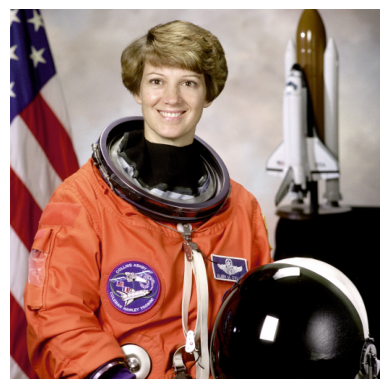

(512, 512, 3)

In [3]:
import matplotlib.pyplot as plt
from skimage import data

img = data.astronaut()
plt.imshow(img)
plt.axis("off")
plt.show()
img.shape

Wyodrębniliśmy poszczególne kanały kolorystyczne.

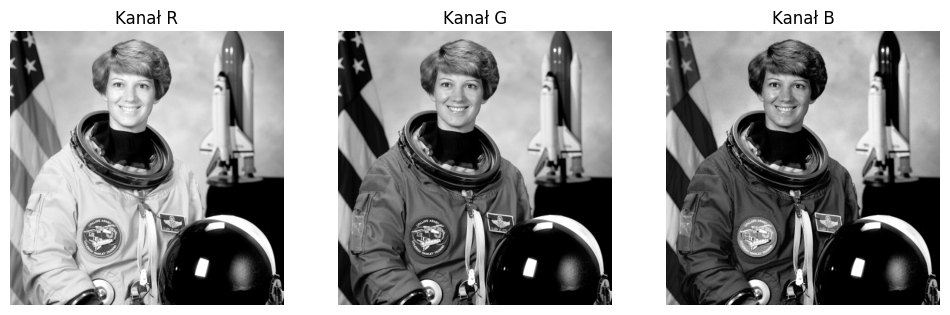

In [2]:
r = img[:, :, 0]
g = img[:, :, 1]
b = img[:, :, 2]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(r, cmap="gray")
ax[0].axis("off")
ax[0].set_title("Kanał R")
ax[1].imshow(g, cmap="gray")
ax[1].axis("off")
ax[1].set_title("Kanał G")
ax[2].imshow(b, cmap="gray")
ax[2].axis("off")
ax[2].set_title("Kanał B")
plt.show()


### Wartości osobliwe
Dla każdej z macierzy R G i B prezentujemy wartości osobliwe, uzyskane w wyniku działania SVD.

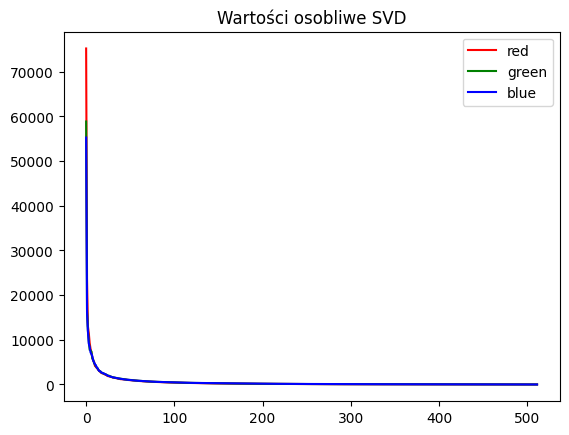

In [3]:
from numpy.linalg import svd

_, singular_values_r, _ = svd(r)
_, singular_values_g, _ = svd(g)
_, singular_values_b, _ = svd(b)

plt.plot(singular_values_r, color="red")
plt.plot(singular_values_g, color="green")
plt.plot(singular_values_b, color="blue")
plt.title("Wartości osobliwe SVD")
plt.legend(["red", "green", "blue"])
plt.show()

SVD zwraca wartości w porządku niemalejącym. Widzimy, że na początku pojawia się kilka bardzo dużych, a potem gwałtownie one maleją. Oznacza to, że o ile kilka pierwszych wartości własnych koduje ważnej informacje, to wszystkie następne zawierają tej informacji coraz mniej. Z tego powodu wydaje się sensownym branie jedynie kilku pierwszych wartości własnych, a nie wszystkich dostępnych.

### Analiza algorytmu kompresji

Uruchamiając nasz algorytm, podamy dwa główne parametry:
- *rank* (ustawiane w parametrze konstruktora klasy TreeNode) — maksymalna liczba wartości osobliwych, które będą brane pod uwagę przy kompresji macierzy,
- *epsilon* — minimalna wartość osobliwa, jaka będzie brana pod uwagę.

W ramach testu wykorzystamy następujące parametry:
- rank $\in \{1, 4\}$
- epsilon ustawimy przy pierwszym teście na pierwszą wartość osobliwą oryginalnej macierzy, za drugim na ostatnią (czyli zejdziemy do pojedynczych liczb), a za trzecim do wartości osobliwej występującej w połowie.

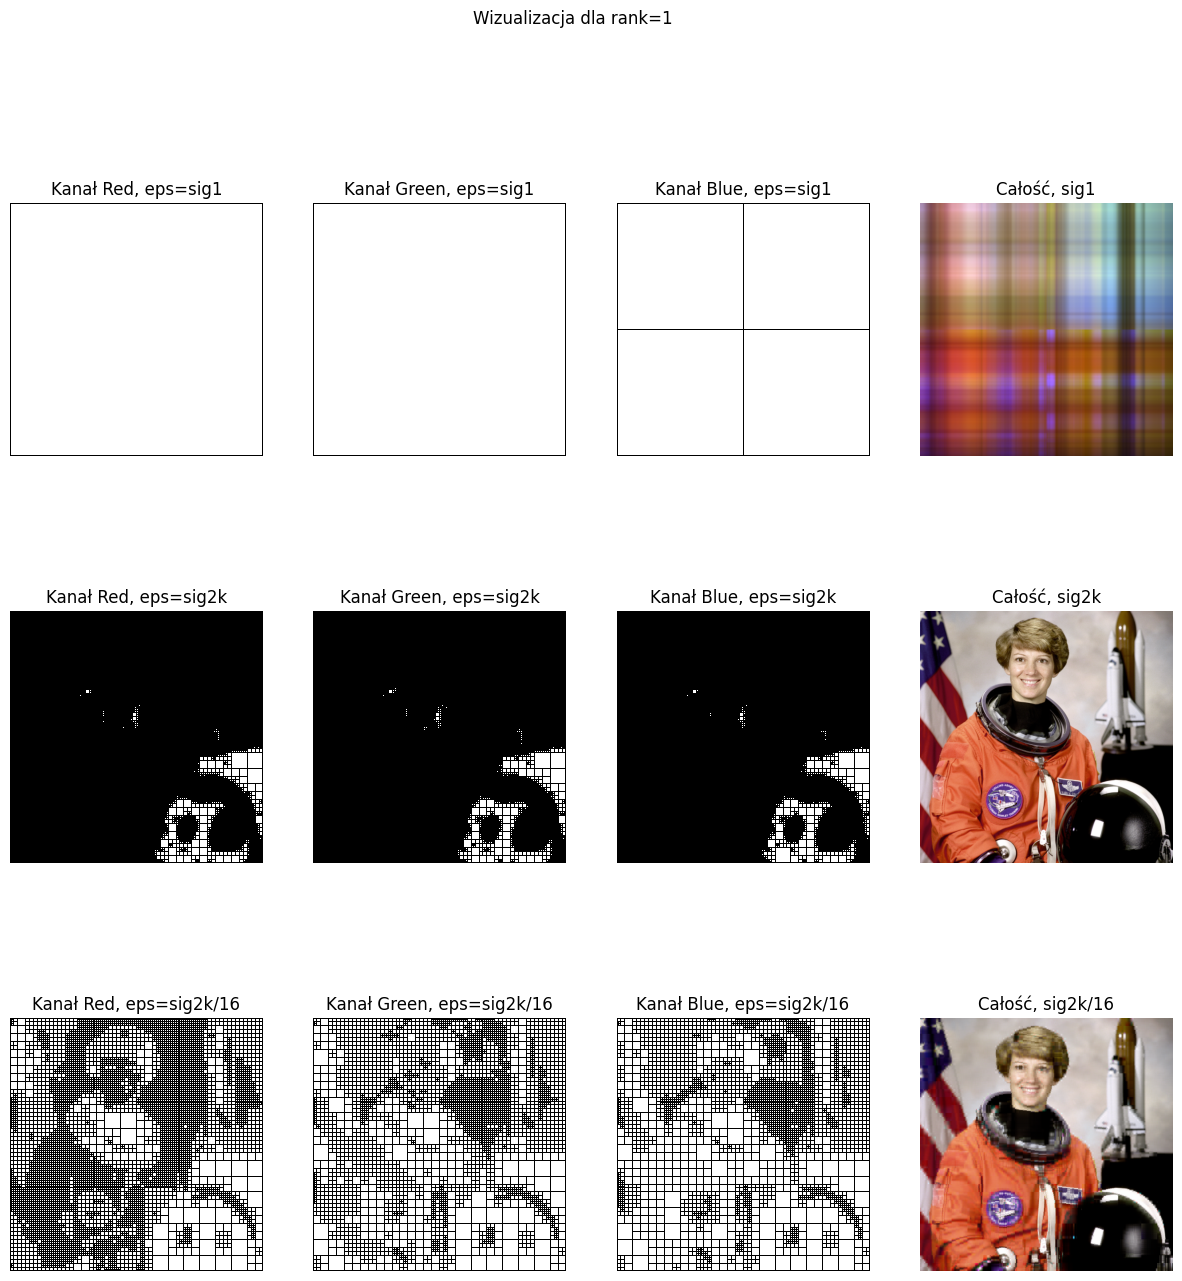

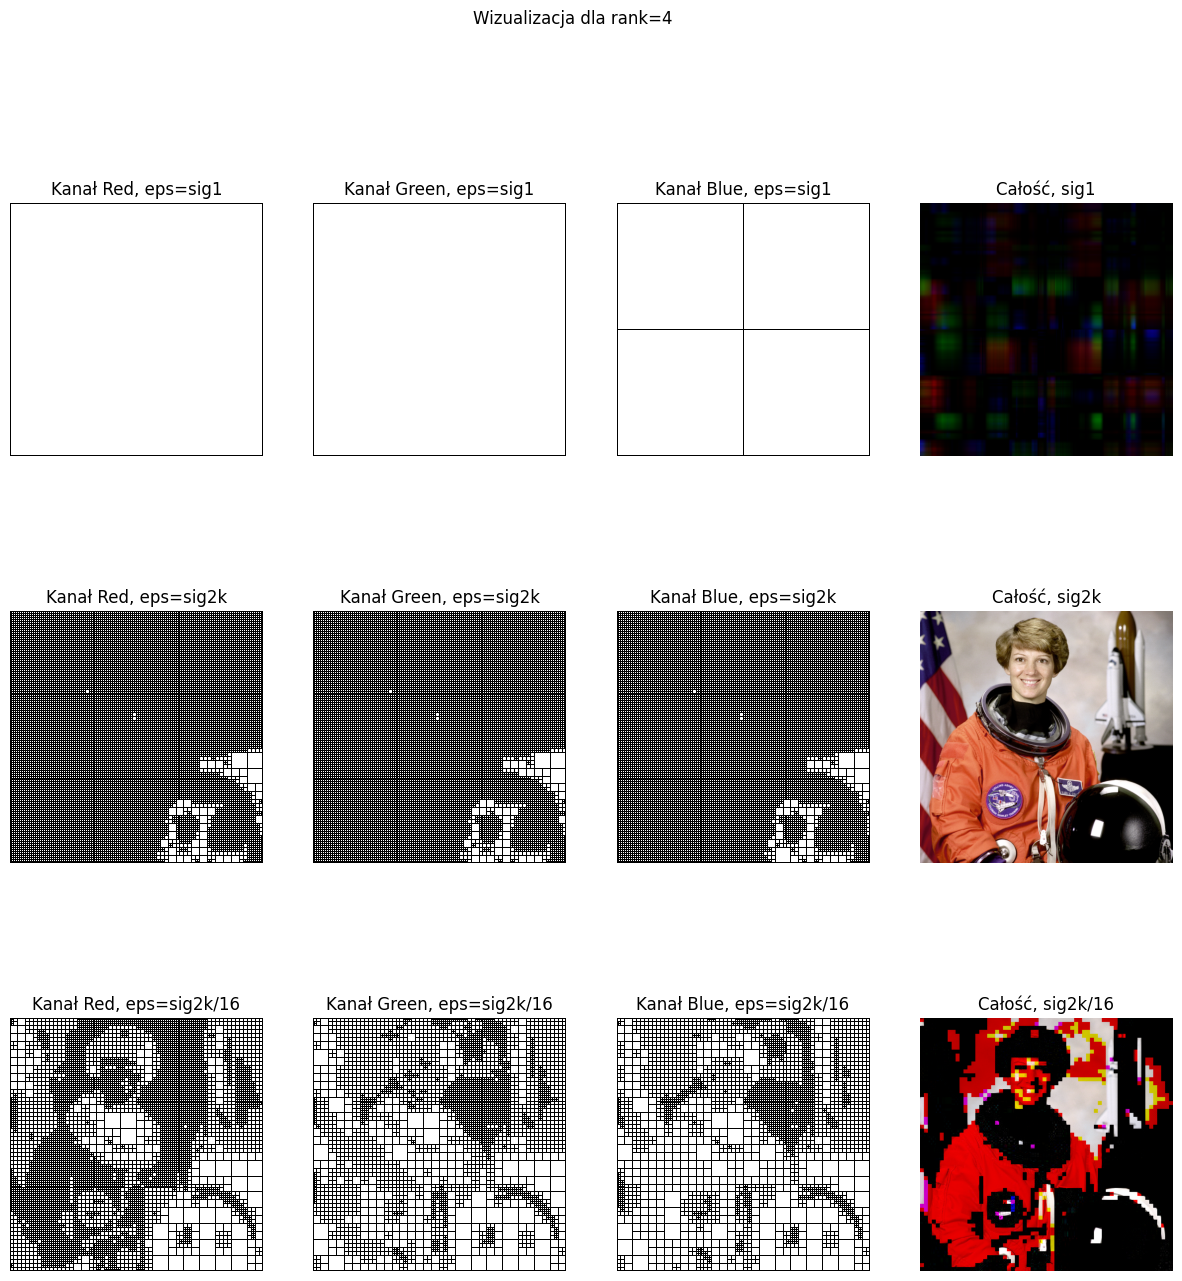

In [5]:
from TreeNode import TreeNode
import numpy as np

def test_with_params(img, rank):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    fig, ax = plt.subplots(3, 4, figsize=(15, 15))

    fig.suptitle(f"Wizualizacja dla rank={rank}")

    processed_layers = []

    for index, (layer, description) in enumerate([(r, "Red"), (g, "Green"), (b, "Blue")]):
        _, singular_values_layer, _ = svd(layer)
        layer_eps1 = TreeNode(rank, (0, 0, layer.shape[0], layer.shape[1]), layer)
        layer_eps1.compress_matrix(singular_values_layer[0])

        layer_eps2 = TreeNode(rank, (0, 0, layer.shape[0], layer.shape[1]), layer)
        layer_eps2.compress_matrix(singular_values_layer[-1])

        layer_eps3 = TreeNode(rank, (0, 0, layer.shape[0], layer.shape[1]), layer)
        layer_eps3.compress_matrix(singular_values_layer[singular_values_layer.shape[0] // 16])

        processed_layers.append(layer_eps1)
        ax[0][index].imshow(layer_eps1.create_structure_image(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax[0][index].set_title(f"Kanał {description}, eps=sig1")
        ax[0][index].axis("off")

        processed_layers.append(layer_eps2)
        ax[1][index].imshow(layer_eps2.create_structure_image(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax[1][index].set_title(f"Kanał {description}, eps=sig2k")
        ax[1][index].axis("off")

        processed_layers.append(layer_eps3)
        ax[2][index].imshow(layer_eps3.create_structure_image(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax[2][index].set_title(f"Kanał {description}, eps=sig2k/16")
        ax[2][index].axis("off")


    for index, sigma in enumerate(["sig1", "sig2k", "sig2k/16"]):
        red_rec = processed_layers[index].reconstruct_image()
        green_rec = processed_layers[index + 3].reconstruct_image()
        blue_rec = processed_layers[index + 6].reconstruct_image()

        full_img = np.dstack((red_rec, green_rec, blue_rec))
        ax[index][-1].imshow(full_img)
        ax[index][-1].set_title(f"Całość, {sigma}")
        ax[index][-1].axis("off")

for rank in [1, 4]:
    test_with_params(img, rank)

Na powyższych ilustracjach przedstawiliśmy 3 różne stopnie "dokładności" kompresji, w zależności od użytego epsilona:
- epsilon równy pierwszej wartości osobliwej oryginalnego SVD
- epsilon równy ostatniej wartości osobliwej oryginalnego SVD
- epsilon równy wartości osobliwej numer $\frac{512}{16} = 32$ (tutaj odeszliśmy nieco od oryginalnego tematu zadania, ale uzyskaliśmy dzięki temu ciekawszy efekt).

Pierwsze dwie opcje prezentują kompresję bardzo stratną i bezstratną. Widzimy, że zastosowanie minimalnego epsilona sprawiło, że algorytm podzielił praktycznie cały obrazek (poza jego bardzo czarną częścią) na malutkie kwadraty. Z kolei użycie epsilona największego sprawiło, że zazwyczaj podział kończył się na jednym kwadracie (ewentualnie na kilku, kwestia porównywania floatów), przez co wynikowa bitmapa wydaje się dość "losowa". Ostatnia opcja najbardziej nas zaciekawiła, gdyż pokazuje ona kompresję, w której wprawdzie obraz jest zniekształcony (rank-1) albo wręcz staje się "mozaikowaty" (rank-4), ale jednak wciąż da się go wizualnie powiązać z oryginałem.

## Podsumowanie
Laboratorium pozwoliło nam zapoznać się z techniką hierarchicznej kompresji macierzy poprzez sprowadzanie ich do postaci Rank-1 przy użyciu SVD. Mieliśmy także okazję w praktyce zastosować te umiejętności, kompresując bitmapę.

### Obrazek do -1

In [9]:
from TreeNode import SVD
import numpy as np

In [55]:
def reconstruct_inverse_image(img: np.ndarray):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    def reconstruct_channel(channel):
        svd = np.linalg.svd(channel, full_matrices=False)
        U, S, Vt = svd[0], svd[1][::-1], svd[2]
        S_inv = np.where(S > 1e-15, 1/S, 0)
        channel_reconstructed = (Vt.T * S_inv) @ U.T
        return channel_reconstructed

    r_rec = reconstruct_channel(r)
    g_rec = reconstruct_channel(g)
    b_rec = reconstruct_channel(b)

    full_img_rec = np.dstack((r_rec, g_rec, b_rec))
    plt.imshow(full_img_rec)
    plt.axis("off")
    plt.title("Rekonstrukcja za pomocą odwrotności SVD")
    plt.show()

    return r, g, b, r_rec, g_rec, b_rec

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.021756463949836206..0.06310044283269735].


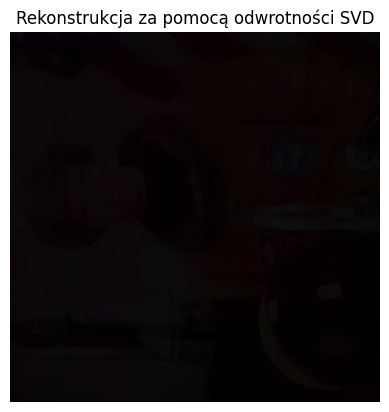

In [56]:
r, g, b, r_rec, g_rec, b_rec = reconstruct_inverse_image(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [972.5576078803359..96681.29176059212].


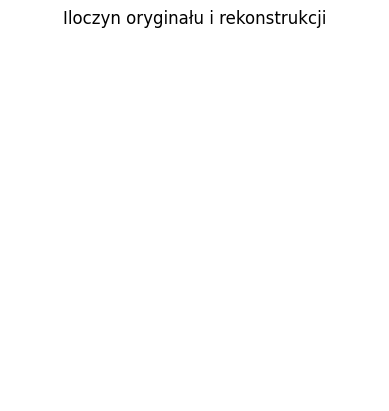

In [58]:
r = r_rec @ r
g = g_rec @ g
b = b_rec @ b
full_img_final = np.dstack((r, g, b))
plt.imshow(full_img_final)
plt.axis("off")
plt.title("Iloczyn oryginału i rekonstrukcji")
plt.show()